In [1]:
from pyspark.sql import SparkSession
# 1. Khởi tạo Spark Session kết nối đến Master chung của cụm
spark = SparkSession.builder \
    .appName("MetroPT3_Machine_Learning") \
    .master("spark://10.125.222.18:7077") \
    .config("spark.executor.memory", "2g") \
    .getOrCreate()
# 2. Đường dẫn nạp dữ liệu sạch đã lưu trên HDFS
HDFS_ML = "hdfs://10.125.222.18:9000/user/bigdata/cleaned/metropt3_clean_for_sql"
df_classification = spark.read.parquet(HDFS_ML)
# 4. Kiểm tra cấu trúc dữ liệu để bắt đầu làm Classification
df_classification.printSchema()
print(f"Tổng số bản ghi: {df_classification.count()}")

root
 |-- _c0: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- TP2: double (nullable = true)
 |-- TP3: double (nullable = true)
 |-- H1: double (nullable = true)
 |-- DV_pressure: double (nullable = true)
 |-- Reservoirs: double (nullable = true)
 |-- Oil_temperature: double (nullable = true)
 |-- Motor_current: double (nullable = true)
 |-- COMP: integer (nullable = true)
 |-- DV_electric: integer (nullable = true)
 |-- Towers: integer (nullable = true)
 |-- MPG: integer (nullable = true)
 |-- LPS: integer (nullable = true)
 |-- Pressure_switch: integer (nullable = true)
 |-- Oil_level: integer (nullable = true)
 |-- Caudal_impulses: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- dow: integer (nullable = true)

Tổng số bản ghi: 1516948


In [2]:
# Cấu trúc lưu trữ Failure Windows chính thức phục vụ đối chiếu trục thời gian
# Định dạng: (Mã sự cố, Thời điểm bắt đầu, Thời điểm kết thúc, Loại sự cố)
FAILURE_WINDOWS = [
    ("F1", "2020-04-18 00:00:00", "2020-04-18 23:59:59", "Air Leak"),
    ("F2", "2020-05-29 23:30:00", "2020-05-30 06:00:00", "Air Leak"),
    ("F3", "2020-06-05 10:00:00", "2020-06-07 14:30:00", "Air Leak"),
    ("F4", "2020-07-15 14:30:00", "2020-07-15 19:00:00", "Air Leak")
]


In [3]:
from functools import reduce
import pyspark.sql.functions as F
def build_label_conditions(timestamp_col="timestamp", horizon_hours=4):
    pre_conditions = []
    failure_conditions = []
    for fid, start, end, ftype in FAILURE_WINDOWS:
        # Chuyển đổi chuỗi thời gian tĩnh sang kiểu dữ liệu Timestamp của Spark
        failure_start = F.lit(start).cast("timestamp")
        failure_end = F.lit(end).cast("timestamp")
        # Thiết lập mốc thời gian bắt đầu quét cảnh báo dựa trên Horizon Hours
        pre_start = F.expr(f"timestamp('{start}') - INTERVAL {horizon_hours} HOURS")
        # Điều kiện cho nhãn Pre-Failure (Giai đoạn suy thoái tiệm tiến)
        pre_cond = (
            (F.col(timestamp_col) >= pre_start) &
            (F.col(timestamp_col) < failure_start)
        )
        # Điều kiện cho nhãn Failure Window (Giai đoạn thiết bị đang gặp sự cố)
        failure_cond = (
            (F.col(timestamp_col) >= failure_start) &
            (F.col(timestamp_col) <= failure_end)
        )
        pre_conditions.append(pre_cond)
        failure_conditions.append(failure_cond)
    # Sử dụng toán tử toán học rút gọn (OR) để gộp chuỗi điều kiện trên toàn cụm dữ liệu
    pre_any = reduce(lambda a, b: a | b, pre_conditions)
    failure_any = reduce(lambda a, b: a | b, failure_conditions)
    return pre_any, failure_any

In [4]:
# Cấu hình xuống 4 giờ để đáp ứng quy định kỹ thuật di tản tàu tối thiểu 2 giờ
HORIZON_HOURS = 4
# Khởi tạo các điều kiện logic lọc dữ liệu
pre_any, failure_any = build_label_conditions(
    timestamp_col="timestamp",
    horizon_hours=HORIZON_HOURS
)
# Tiến hành gán nhãn phân loại
df_labeled_raw = df_classification.withColumn(
    "label",
    F.when(failure_any, F.lit(None).cast("double")) # Đánh dấu Null để loại bỏ giai đoạn hỏng
     .when(pre_any, F.lit(1.0))                     # Nhãn 1: Giai đoạn cảnh báo sớm nguy cơ
     .otherwise(F.lit(0.0))                         # Nhãn 0: Máy vận hành bình thường ổn định
).withColumn(
    "is_failure_window",
    F.when(failure_any, F.lit(1)).otherwise(F.lit(0))
)
# Loại bỏ hoàn toàn các dòng dữ liệu thuộc khoảng thời gian hỏng
classification_df = df_labeled_raw.filter(F.col("label").isNotNull())
classification_df.cache()
print(f"Tổng số dòng sau khi lọc sạch Failure Windows: {classification_df.count()}")
print("Thống kê số lượng bản ghi theo nhãn phân loại (Classification Input):")
classification_df.groupBy("label").count().orderBy("label").show()
print("Số lượng mẫu thuộc giai đoạn sự cố đã được phân tách thành công:")
df_labeled_raw.groupBy("is_failure_window").count().show()

Tổng số dòng sau khi lọc sạch Failure Windows: 1486988
Thống kê số lượng bản ghi theo nhãn phân loại (Classification Input):
+-----+-------+
|label|  count|
+-----+-------+
|  0.0|1481437|
|  1.0|   5551|
+-----+-------+

Số lượng mẫu thuộc giai đoạn sự cố đã được phân tách thành công:
+-----------------+-------+
|is_failure_window|  count|
+-----------------+-------+
|                1|  29960|
|                0|1486988|
+-----------------+-------+



In [5]:
# Tính toán tổng số lượng mẫu hợp lệ phục vụ phép chia tỷ lệ phần trăm
total_rows = classification_df.count()
# Chạy bảng thống kê phân phối
label_dist = classification_df.groupBy("label") \
    .agg(F.count("*").alias("count")) \
    .withColumn("ratio_percent", F.round(F.col("count") / F.lit(total_rows) * 100, 4)) \
    .orderBy("label")
print("Bảng phân phối nhãn")
label_dist.show()

Bảng phân phối nhãn
+-----+-------+-------------+
|label|  count|ratio_percent|
+-----+-------+-------------+
|  0.0|1481437|      99.6267|
|  1.0|   5551|       0.3733|
+-----+-------+-------------+



In [6]:
# PHÂN LOẠI CẢM BIẾN: Tách biệt tín hiệu Analog (Liên tục) và Digital (Rời rạc). Đã loại bỏ LPS.
analog_cols = ["TP2", "TP3", "H1", "DV_pressure", "Reservoirs", "Oil_temperature", "Motor_current"]
digital_cols_no_lps = ["COMP", "DV_eletric", "Towers", "MPG", "Start_signal", "Stop_signal", "Error_signal"]

In [7]:
from pyspark.sql.window import Window
import pyspark.sql.functions as F
# 1. Đặc trưng Không gian: Độ sụt áp tổng thể (Tín hiệu rò rỉ cốt lõi)
classification_fe_df = classification_df.withColumn(
    "pressure_delta_tp3_tp2",
    F.col("TP3") - F.col("TP2")
)
# 2. Đặc trưng Thời gian: Cửa sổ trượt 15 phút (900 giây)
w_15m = Window.orderBy(F.col("timestamp").cast("long")).rangeBetween(-900, 0)
classification_fe_df = classification_fe_df \
    .withColumn("TP2_rolling_mean_15m", F.avg("TP2").over(w_15m)) \
    .withColumn("Motor_rolling_mean_15m", F.avg("Motor_current").over(w_15m)) \
    .withColumn("pressure_delta_mean_15m", F.avg("pressure_delta_tp3_tp2").over(w_15m)) \
    .withColumn("pressure_delta_std_15m", F.stddev("pressure_delta_tp3_tp2").over(w_15m))
# 3. Lưu trữ cấu hình biến nhân tạo
engineered_continuous_cols = [
    "pressure_delta_tp3_tp2",
    "TP2_rolling_mean_15m",
    "Motor_rolling_mean_15m",
    "pressure_delta_mean_15m",
    "pressure_delta_std_15m"
]

In [8]:
import pyspark.sql.functions as F
# 1. Cắt bỏ tàn dư toán học (Dòng Null sinh ra do lùi 15 phút ở đầu chuỗi thời gian)
classification_df_clean = classification_fe_df.dropna(subset=engineered_continuous_cols)
# 2. Đóng gói danh sách biến toàn cục
final_feature_cols = analog_cols + digital_cols_no_lps + engineered_continuous_cols
# 3. Báo cáo nghiệm thu luồng dữ liệu
print(f"-> Tổng số lượng biến đưa vào mô hình: {len(final_feature_cols)} biến.")
print("-> Bảng kiểm tra khuyết thiếu (Phải trả về toàn bộ 0):")
classification_df_clean.select([
    F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c)
    for c in engineered_continuous_cols
]).show()

-> Tổng số lượng biến đưa vào mô hình: 19 biến.
-> Bảng kiểm tra khuyết thiếu (Phải trả về toàn bộ 0):
+----------------------+--------------------+----------------------+-----------------------+----------------------+
|pressure_delta_tp3_tp2|TP2_rolling_mean_15m|Motor_rolling_mean_15m|pressure_delta_mean_15m|pressure_delta_std_15m|
+----------------------+--------------------+----------------------+-----------------------+----------------------+
|                     0|                   0|                     0|                      0|                     0|
+----------------------+--------------------+----------------------+-----------------------+----------------------+



In [9]:
import pyspark.sql.functions as F
# 1. Danh sách các cột CẤM (Định danh, rò rỉ, đáp án)
banned_cols = ["label", "timestamp", "is_failure_window", "_c0", "index", "LPS",
    "hour", "month", "dow"]
baseline_features = [c for c in classification_df_clean.columns if c not in banned_cols]
# Phân tách Train/Test theo mốc thời gian
SPLIT_DATE = "2020-06-01 00:00:00"
train_df = classification_df_clean.filter(F.col("timestamp") < F.lit(SPLIT_DATE).cast("timestamp"))
test_df = classification_df_clean.filter(F.col("timestamp") >= F.lit(SPLIT_DATE).cast("timestamp"))
# 3. Tối ưu hóa bộ nhớ
classification_df_clean.unpersist()
train_df.cache()
test_df.cache()
print(f"-> Đã tự động nhận diện và quét được {len(baseline_features)} biến Baseline.")
print(f"-> Dữ liệu Train: {train_df.count()} dòng | Dữ liệu Test: {test_df.count()} dòng.")

-> Đã tự động nhận diện và quét được 19 biến Baseline.
-> Dữ liệu Train: 845684 dòng | Dữ liệu Test: 641092 dòng.


In [10]:
import pyspark.sql.functions as F
from pyspark.ml.feature import VectorAssembler
import pandas as pd
THRESHOLD = 0.1
variance_exprs = [F.variance(F.col(c)).alias(c) for c in baseline_features]
variance_row = train_df.select(variance_exprs).first()
var_data = []
var_survived_features = []
for c in baseline_features:
    val = variance_row[c]
    var_data.append({"Feature": c, "Variance": val})
    if val is not None and val > THRESHOLD:
        var_survived_features.append(c)
display(pd.DataFrame(var_data).sort_values(by="Variance", ascending=False))

assembler = VectorAssembler(
    inputCols=var_survived_features,
    outputCol="var_features",
    handleInvalid="skip"
)
train_filtered = assembler.transform(train_df)
test_filtered = assembler.transform(test_df)

,Feature,Variance
5,Oil_temperature,40.470338
2,H1,9.304849
14,pressure_delta_tp3_tp2,9.176354
0,TP2,8.919651
6,Motor_current,4.988981
17,pressure_delta_mean_15m,3.255371
15,TP2_rolling_mean_15m,2.891248
18,pressure_delta_std_15m,2.154579
16,Motor_rolling_mean_15m,1.858882
1,TP3,0.392573


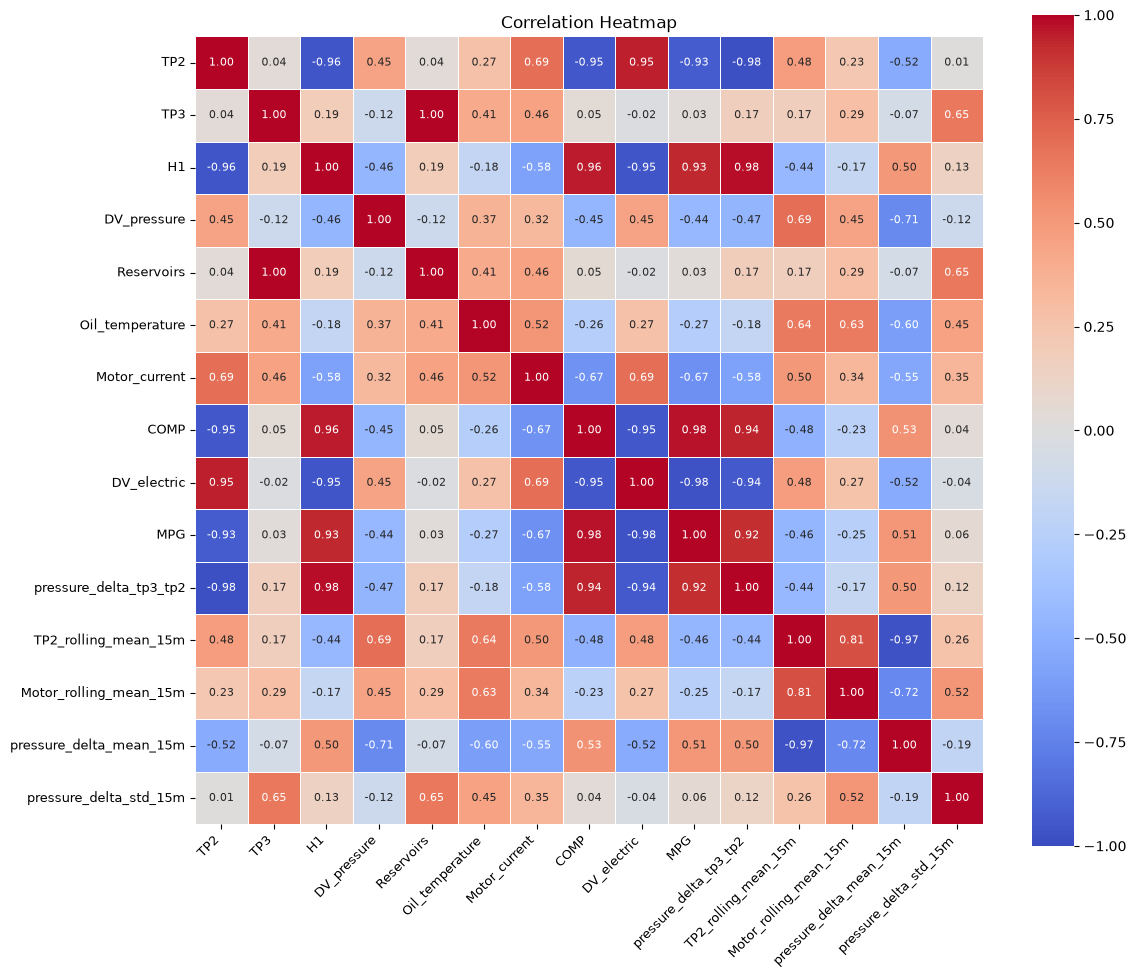

,Feature 1,Feature 2,Correlation
1,Reservoirs,TP3,0.999992
12,pressure_delta_tp3_tp2,H1,0.983922
9,MPG,COMP,0.975187
3,COMP,H1,0.960426
4,DV_electric,TP2,0.946972
13,pressure_delta_tp3_tp2,COMP,0.943911
8,MPG,H1,0.933763
15,pressure_delta_tp3_tp2,MPG,0.917699
7,MPG,TP2,-0.925067
14,pressure_delta_tp3_tp2,DV_electric,-0.937315


In [11]:
from pyspark.ml.stat import Correlation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Tính toán ma trận Pearson
pearson_matrix = Correlation.corr(train_filtered, "var_features", "pearson").head()[0]
corr_df = pd.DataFrame(pearson_matrix.toArray(), index=var_survived_features, columns=var_survived_features)
# Trực quan hóa Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_df, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, square=True, linewidths=0.5, annot_kws={"size": 8}
)
plt.title("Correlation Heatmap", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()
# Xuất danh sách các cặp biến tương quan cực đoan (|r| > 0.9)
high_corr = []
for i in range(len(corr_df.columns)):
    for j in range(i):
        if abs(corr_df.iloc[i, j]) > 0.9:
            high_corr.append({"Feature 1": corr_df.columns[i], "Feature 2": corr_df.columns[j], "Correlation": corr_df.iloc[i, j]})

if high_corr:
    display(pd.DataFrame(high_corr).sort_values(by="Correlation", ascending=False))